# Cost Function in Action — Mean Squared Error, Step by Step

Source: this notebook is the hands-on follow-up promised at the end of
[`29_Cost_Function.MD`](29_Cost_Function.MD) — "*the hands-on notebook for
Cost Function (and likely Gradient Descent together), once we're ready to
go practical.*" It also acts directly on two screenshots from the course
(the "Regression Cost Function" whiteboard slide and the "Mean Squared
Error" formula slide) plus notes taken while watching.

`29` explained cost functions with words, one hand-drawn bowl curve, and a
3-row pen-and-paper example. This notebook proves every one of those claims
with real code, real numbers, and real charts, using the same `cgpa` →
`package` dataset from [`25`](25_Simple_Linear_Regression.MD) /
[`26`](26_Simple_Linear_Regression.ipynb).

By the end of this notebook we will have:

1. Plotted a bad guess line and a decent guess line, and *seen* the errors
   the course slide draws as red triangles.
2. Built the Mean Squared Error formula ourselves, in plain numpy — no
   library shortcut.
3. Proven, with numbers, why the error gets **squared** instead of just
   subtracted.
4. Drawn the "cost bowl" from `29` for real, by actually computing MSE
   across a range of slopes — not sketching it.
5. Implemented Gradient Descent from scratch — the exact rule from the
   notes: `mNew = mOld - learningRate × (dL/dm)` — and watched the line
   **redraw itself again and again** until it lands on the best fit.
6. Checked our from-scratch result against `scikit-learn`'s answer, to
   prove it's actually correct.
7. Tested whether "MSE is robust to outliers" — and shown, with real
   numbers, that it is exactly the opposite.

**Every code cell below has a one- or two-line note right above it saying
what that specific cell does**, on top of the usual inline `#` comments —
so this should be readable on its own, without re-reading the whole
notebook top to bottom, if you come back to it later.


## Step 1 — Load the same dataset as before

Reusing `placement.csv` (`cgpa` → `package`) from `25`/`26`/`29`, so every
number in this notebook is directly comparable to what came before.

This cell does three things: bring in the three libraries we need
(pandas for tables, numpy for math, matplotlib for charts), load the CSV
into a table called `dataset`, and print the first 5 rows just to confirm
it loaded correctly.

In [1]:
import pandas as pd    # pandas: load the CSV and work with it as a table
import numpy as np     # numpy: arrays, sums, means -- all the math below
import matplotlib.pyplot as plt   # matplotlib: every chart in this notebook

dataset = pd.read_csv("placement.csv")   # same 100-row file used in 25, 26, 29
dataset.head()                           # peek at the first 5 rows -- sanity check

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Pull `cgpa` and `package` out of the table as plain numpy arrays —
these become `x` and `y`, the two things every formula below works with.
`n` is just the row count, used by the `(1/n) × Σ` part of the MSE
formula.

In [2]:
x = dataset["cgpa"].values      # independent variable, as a plain numpy array
y = dataset["package"].values   # dependent variable (actual values), as a plain numpy array
n = len(x)                      # how many rows/students we have -- the "n" in every formula below
n

100

Plot every row as a dot — `cgpa` along the bottom, `package` up the
side — with no line drawn yet. Just the raw shape of the data, for
reference before anything gets fitted to it.

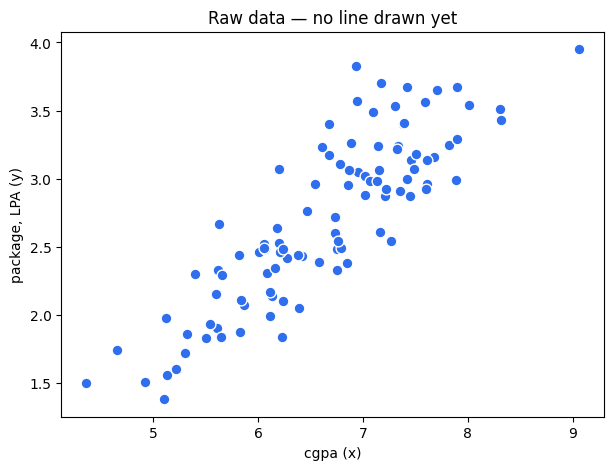

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(x, y, color="#2f6fed", edgecolor="white", s=60)
plt.xlabel("cgpa (x)")
plt.ylabel("package, LPA (y)")
plt.title("Raw data — no line drawn yet")
plt.show()

## Step 2 — Try two candidate lines

The first screenshot shows a line drawn, then **redrawn several times**,
with red triangles marking "ERROR" wherever a point is far from the line.
**That full redraw-again-and-again sequence is what Gradient Descent does
for real, later, in Step 7–8** — the `for epoch in ...` loop there is
where the line actually gets redrawn multiple times and walks toward the
best fit.

Here, as a warm-up, we just freeze **two single frames** of that idea by
hand: one bad guess for `(m, c)` and one decent guess, so we can look at
the gaps by eye before we ever put a number on them.

`predict()` below is just `y = m·x + c` from `25` — nothing new.

Define the model itself: given a slope `m`, an intercept `c`, and
some `x` values, `predict()` returns the line's `ŷ` for every one of
them, all at once (numpy applies the formula to the whole array).

In [4]:
def predict(x, m, c):
    return m * x + c   # the whole model: multiply slope by x, then shift by intercept

Pick the two guesses: `m_bad, c_bad` is a careless, too-flat line;
`m_decent, c_decent` is close to the true best-fit line (confirmed later,
in Step 9). Run both through `predict()` to get a predicted `ŷ` for every
one of the 100 rows.

In [5]:
m_bad, c_bad = 0.1, 0.5            # a careless guess -- too flat, shifted up
m_decent, c_decent = 0.59, -1.23  # close to the true best-fit line (checked later in Step 9)

y_hat_bad = predict(x, m_bad, c_bad)        # predicted package for every row, using the bad line
y_hat_decent = predict(x, m_decent, c_decent)  # predicted package for every row, using the decent line
y_hat_bad[:5], y_hat_decent[:5]

(array([1.189, 1.012, 1.282, 1.242, 1.194]),
 array([2.8351, 1.7908, 3.3838, 3.1478, 2.8646]))

Plot both lines over the same scatter, plus a thin vertical bar
from every actual point down to the *bad* line — that bar is one row's
error, the same "red triangle" idea from the screenshot, just drawn as a
line instead of a triangle marker.

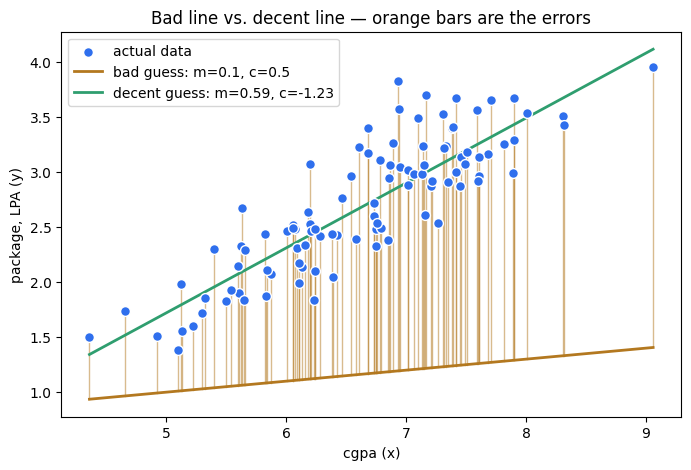

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="#2f6fed", edgecolor="white", s=50, label="actual data", zorder=3)

# vertical error bars for the bad line only — this is the "red triangle" picture from the screenshot
for xi, yi, yhi in zip(x, y, y_hat_bad):
    plt.plot([xi, xi], [yi, yhi], color="#b3781f", linewidth=1, alpha=0.5, zorder=1)

order = np.argsort(x)   # sort by x first, otherwise plt.plot() draws a zig-zag instead of a straight line
plt.plot(x[order], y_hat_bad[order], color="#b3781f", linewidth=2, label=f"bad guess: m={m_bad}, c={c_bad}")
plt.plot(x[order], y_hat_decent[order], color="#2f9e6f", linewidth=2, label=f"decent guess: m={m_decent}, c={c_decent}")
plt.xlabel("cgpa (x)")
plt.ylabel("package, LPA (y)")
plt.title("Bad line vs. decent line — orange bars are the errors")
plt.legend()
plt.show()

Just by eye, the green line hugs the dots far better than the orange
one — the orange vertical bars (the errors) are long and one-sided, mostly
sitting *above* the line because the bad line is too flat and shifted too
high. "Looks better" still isn't a number though — that's what Step 3
fixes.

## Step 3 — Build Mean Squared Error ourselves

Straight from the course's formula slide:

```
MSE = (1/n) × Σ (yᵢ − ŷᵢ)²
```

In plain English: for every row, take (actual − predicted), square it, add
all of those up, then divide by how many rows there are. No
`scikit-learn` helper here — this is the formula typed out by hand so
there's no doubt what it's actually doing.

In [7]:
def mean_squared_error(y_actual, y_predicted):
    errors = y_actual - y_predicted   # actual minus predicted, one number per row
    squared_errors = errors ** 2      # square each one -- negatives become positive, big misses grow fast
    return np.mean(squared_errors)    # average across every row -- the formula's (1/n) x sum

Now measure both guesses from Step 2 with this real formula,
instead of just eyeballing the chart.

In [8]:
mse_bad = mean_squared_error(y, y_hat_bad)
mse_decent = mean_squared_error(y, y_hat_decent)
mse_bad, mse_decent

(np.float64(2.6509399899999995), np.float64(0.09556856790000001))

**The decent line's MSE is much smaller than the bad line's.** That's
the whole point of a cost function from `29`, now backed by an actual
number instead of a vibe: smaller MSE = better line, and now we have a way
to *compare* any two candidate lines objectively.

## Step 4 — Why square the errors instead of just subtracting?

`29`'s FAQ claimed raw (unsquared) differences can cancel out. Let's check
that claim on our own decent line instead of taking it on faith — compute
the plain, unsquared error for every row and average those directly.

In [9]:
raw_errors = y - y_hat_decent          # actual minus predicted, NOT squared this time
mean_raw_error = np.mean(raw_errors)   # average of the raw (signed) errors
mean_raw_error

np.float64(0.019351000000000226)

Now put that raw-error average side by side with the squared
version from Step 3, computed on the exact same line.

In [10]:
mean_squared_error_decent = mean_squared_error(y, y_hat_decent)
mean_raw_error, mean_squared_error_decent

(np.float64(0.019351000000000226), np.float64(0.09556856790000001))

The **mean of the raw errors is close to zero** — points above the
line and points below the line cancel each other out almost completely,
even though the line is clearly missing plenty of points by a fair
margin. If we tried to minimize *that* number, the model would think it's
already almost perfect. Squaring first (`mean_squared_error_decent`) forces
every error positive before averaging, so misses can't hide behind each
other — which is exactly what the "Error in square term" note from the
slide is pointing at.

## Step 5 — Draw the cost bowl for real

`29` showed a hand-drawn bowl-shaped curve of cost vs. slope `m`. Let's
actually compute it: hold `c` fixed at the best value found later in
Step 9 (`-1.226`), sweep `m` across a wide range, and calculate real MSE at
every single value.

In [11]:
m_range = np.linspace(-0.5, 1.7, 200)   # 200 candidate slopes to test, evenly spaced
c_fixed = -1.226                        # hold the intercept fixed, so this is a clean 2-D picture

costs = [mean_squared_error(y, predict(x, m_candidate, c_fixed)) for m_candidate in m_range]
costs = np.array(costs)   # one MSE value per candidate slope in m_range
costs[:5]

array([53.48774875, 52.41245013, 51.34808992, 50.29466811, 49.25218471])

Find which of those 200 slopes actually gave the lowest cost —
that's the bottom of the bowl, in real numbers.

In [12]:
best_index = np.argmin(costs)              # position of the smallest cost in the list
best_m_from_sweep = m_range[best_index]    # the slope at that position
best_cost_from_sweep = costs[best_index]   # the cost at that position
best_m_from_sweep, best_cost_from_sweep

(np.float64(0.5944723618090453), np.float64(0.09539817988106362))

Plot cost against candidate slope — the green dot marks the minimum
we just found.

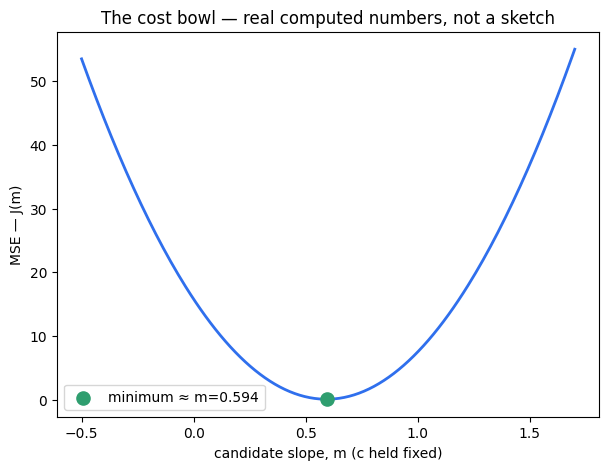

In [13]:
plt.figure(figsize=(7, 5))
plt.plot(m_range, costs, color="#2f6fed", linewidth=2)
plt.scatter([best_m_from_sweep], [best_cost_from_sweep], color="#2f9e6f", s=90, zorder=3,
            label=f"minimum ≈ m={best_m_from_sweep:.3f}")
plt.xlabel("candidate slope, m (c held fixed)")
plt.ylabel("MSE — J(m)")
plt.title("The cost bowl — real computed numbers, not a sketch")
plt.legend()
plt.show()

This is the real version of the hand-drawn curve in `29`: a smooth
bowl with one lowest point. Every `m` too small or too large costs more.
**"Training the model" is nothing more mysterious than finding this exact
dip.** Checking `m` one value at a time in a loop like this is fine for a
demo with one parameter — for real training, that's far too slow and
doesn't scale past one parameter. That's exactly the job Gradient Descent
does next.

## Step 6 — Gradient Descent: turning "walk downhill" into a formula

The note taken while watching already has the right idea:

> "To identify the best fit line, `mNew = mOld - learningRate(dl/dm)`."

That's exactly Gradient Descent. `dl/dm` (the slope of the cost bowl at
the current `m`) tells us which direction is uphill; subtracting a small
step in that direction always moves `downhill`, toward lower cost. The
same update happens for `c` at the same time.

**Where do `dL/dm` and `dL/dc` come from?** They're the calculus
derivative of the MSE formula from Step 3, worked out once and reused as a
fixed recipe — you don't re-derive this every time, the same way you don't
re-derive how `HashMap.get()` works before calling it:

```
dL/dm = -(2/n) × Σ xᵢ (yᵢ − ŷᵢ)
dL/dc = -(2/n) × Σ (yᵢ − ŷᵢ)
```

Then, every step:

```
mNew = mOld − learningRate × dL/dm
cNew = cOld − learningRate × dL/dc
```

`learningRate` controls how big each step downhill is — too small and
training crawls; too large and it overshoots the bottom of the bowl and
can even bounce out of it entirely (tested below).

As code, the two derivatives above become one small function:

In [14]:
def gradients(x, y, m, c):
    y_hat = predict(x, m, c)                     # current line's prediction for every row
    error = y - y_hat                            # how far off each prediction is (signed, not squared)
    dL_dm = -(2 / len(x)) * np.sum(x * error)     # dL/dm from the formula above
    dL_dc = -(2 / len(x)) * np.sum(error)         # dL/dc from the formula above
    return dL_dm, dL_dc

Before picking a real learning rate, deliberately try a big one
(`0.05`) for just 5 steps, to see what "too big" looks like in actual
numbers.

In [15]:
# quick proof that too-large a learning rate breaks Gradient Descent, before we pick a working one
m_test, c_test = 0.0, 0.0
for _ in range(5):
    dL_dm, dL_dc = gradients(x, y, m_test, c_test)
    m_test = m_test - 0.05 * dL_dm   # learning_rate = 0.05, deliberately too big
    c_test = c_test - 0.05 * dL_dc
m_test, c_test   # blown up / not a real slope and intercept -- confirms 0.05 is too large

(np.float64(234.41944710168642), np.float64(34.739234649926246))

`0.05` sends `m` and `c` off to huge, useless numbers within a handful
of steps — it keeps overshooting the bottom of the bowl and flying further
out each time. `0.02` turns out to be small enough to stay stable. That's
found by testing, the same way you'd tune a retry backoff or a rate
limit — there's no formula that hands you the "correct" learning rate up
front.

## Step 7 — Run Gradient Descent, and save snapshots along the way

**This is the step that literally answers "where does the line get drawn
and redrawn multiple times?"** Starting from `m = 0, c = 0` (the flattest,
laziest possible guess), we run 8000 update steps. At a handful of
checkpoints we save a "photo" of the current `(m, c)` — those saved
photos are what get plotted as separate lines in Step 8.

Split into three small cells: first the settings, then the loop itself,
then reading off the final answer.

Settings and empty containers, all in one place before the loop
starts.

In [16]:
learning_rate = 0.02   # step size -- tuned above; 0.05 was too big, 0.02 stays stable
epochs = 8000           # how many times we'll nudge m and c
snapshot_epochs = {0, 1, 2, 5, 20, 100, 1000, epochs}   # which epochs to freeze -- used by the Step 8 plot

m, c = 0.0, 0.0     # start from the flattest, laziest possible guess
cost_history = []   # MSE at every single epoch -- for the "cost vs epoch" plot in Step 8
snapshots = []      # (epoch, m, c) saved only at snapshot_epochs -- these become the redrawn lines

**The loop itself — this is where the line actually gets redrawn,
again and again.** Each pass: maybe save a photo, record the current cost,
then nudge `m` and `c` one step downhill using the exact
`mNew = mOld - learningRate × dL/dm` rule from Step 6.

In [17]:
for epoch in range(epochs + 1):
    if epoch in snapshot_epochs:
        snapshots.append((epoch, m, c))   # freeze a "photo" of the current line -- this IS the redraw
    cost_history.append(mean_squared_error(y, predict(x, m, c)))   # how good is the current line, right now
    if epoch == epochs:
        break   # last epoch: record it, but don't take one more step past it
    dL_dm, dL_dc = gradients(x, y, m, c)   # which way is uphill, from here
    m = m - learning_rate * dL_dm          # step downhill for the slope     -- mNew = mOld - lr * dL/dm
    c = c - learning_rate * dL_dc          # step downhill for the intercept -- cNew = cOld - lr * dL/dc

Whatever `(m, c)` the loop landed on after all 8000 steps is the
trained line — read it off here.

In [18]:
m_final, c_final = m, c   # the line the loop settled on after 8000 steps
m_final, c_final

(np.float64(0.5914952856012292), np.float64(-1.2204698463361396))

Turn the saved snapshots into a table, so `m`, `c`, and MSE can be
watched moving together, epoch by epoch.

In [19]:
progress = pd.DataFrame(snapshots, columns=["epoch", "m", "c"])
progress["MSE"] = [mean_squared_error(y, predict(x, m_i, c_i)) for _, m_i, c_i in snapshots]
progress

,epoch,m,c,MSE
0,0,0.000000,0.000000,7.667213
1,1,0.735035,0.108068,5.311518
2,2,0.125718,0.016850,3.691458
3,5,0.559961,0.078546,1.284112
4,20,0.394813,0.040769,0.127365
5,100,0.414280,-0.025011,0.120258
6,1000,0.495812,-0.575010,0.102555
7,8000,0.591495,-1.220470,0.095190


Look at the `MSE` column top to bottom: `5.31 → 3.69 → ... → 0.095`.
Cost drops fast at first, then flattens out as `(m, c)` gets close to the
bottom of the bowl from Step 5 — the classic shape of Gradient Descent
working correctly. Notice epoch 1 and epoch 2 aren't smoothly decreasing —
`m` overshoots slightly before correcting itself, a smaller, harmless
version of the same overshoot that blew up completely at
`learning_rate = 0.05` above.

## Step 8 — Watch the line redraw itself

This is the exact picture the first screenshot is showing: the same line,
drawn again and again, creeping closer to the data with every redraw. The
loop below draws the scatter once, then adds one line per saved
snapshot from Step 7 — draw, redraw, redraw again.

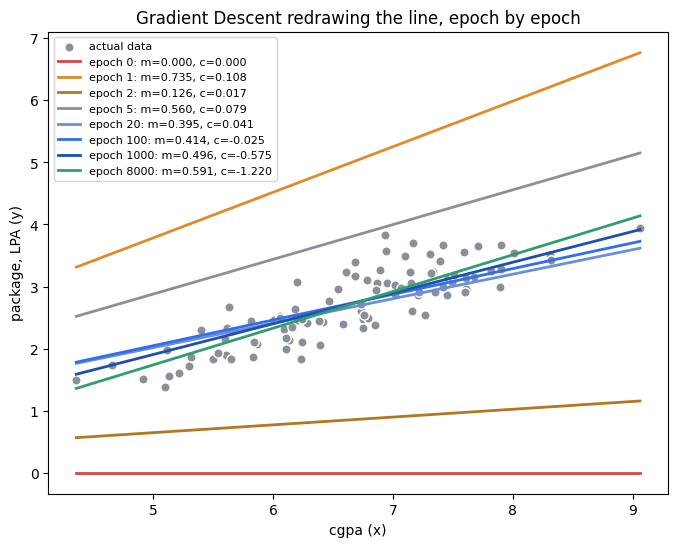

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(x, y, color="#8a8f98", edgecolor="white", s=45, label="actual data", zorder=2)

colors = ["#d64545", "#e08a2b", "#b3781f", "#8a8f98", "#6a8fd8", "#2f6fed", "#1e4fae", "#2f9e6f"]
x_line = np.linspace(x.min(), x.max(), 50)   # smooth set of x-values just for drawing straight lines

for (epoch, m_i, c_i), color in zip(snapshots, colors):
    plt.plot(x_line, predict(x_line, m_i, c_i), color=color, linewidth=2,
              label=f"epoch {epoch}: m={m_i:.3f}, c={c_i:.3f}")   # one redraw per saved snapshot

plt.xlabel("cgpa (x)")
plt.ylabel("package, LPA (y)")
plt.title("Gradient Descent redrawing the line, epoch by epoch")
plt.legend(fontsize=8, loc="upper left")
plt.show()

Same training run, viewed a second way: cost per epoch instead of
lines on the scatter plot.

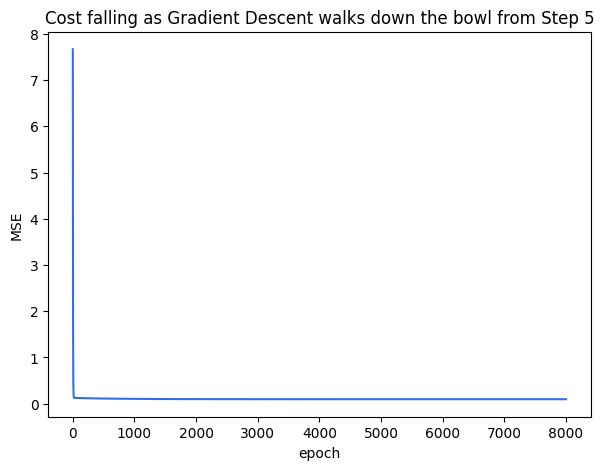

In [21]:
plt.figure(figsize=(7, 5))
plt.plot(range(len(cost_history)), cost_history, color="#2f6fed")
plt.xlabel("epoch")
plt.ylabel("MSE")
plt.title("Cost falling as Gradient Descent walks down the bowl from Step 5")
plt.show()

The first line (epoch 0, flat at `m=0`) is a bad guess. By epoch 20
it already roughly tracks the trend. By the final epoch it sits right on
top of the decent-guess line from Step 2 — Gradient Descent found that line
on its own, using nothing but the slope of the cost bowl at each step.
The cost curve above is the exact same walk, just viewed as "cost over
time" instead of "line over the scatter plot" — two views of one process.

## Step 9 — Sanity check: does this match scikit-learn?

Our from-scratch Gradient Descent should land close to whatever
`scikit-learn`'s `LinearRegression` finds using Ordinary Least Squares
(the closed-form shortcut mentioned in `25`/`29`) on the same data — two
different roads to the same destination.

In [22]:
from sklearn.linear_model import LinearRegression   # scikit-learn's Simple Linear Regression, same as 26

x_2d = dataset[["cgpa"]]     # scikit-learn wants features as a 2-D table, even with just 1 column
y_1d = dataset["package"]    # target stays 1-D

sklearn_model = LinearRegression().fit(x_2d, y_1d)   # .fit() runs Ordinary Least Squares internally
m_sklearn = sklearn_model.coef_[0]     # the slope it found
c_sklearn = sklearn_model.intercept_   # the intercept it found
m_sklearn, c_sklearn

(np.float64(0.5923194539434177), np.float64(-1.2260295310441962))

Line up both answers side by side, plus each one's MSE, to see how
close our from-scratch result really is to the textbook method.

In [23]:
comparison = pd.DataFrame({
    "method": ["Gradient Descent (ours)", "scikit-learn (OLS)"],
    "m": [m_final, m_sklearn],
    "c": [c_final, c_sklearn],
})
comparison["MSE"] = [
    mean_squared_error(y, predict(x, m_final, c_final)),
    mean_squared_error(y, predict(x, m_sklearn, c_sklearn)),
]
comparison

,method,m,c,MSE
0,Gradient Descent (ours),0.591495,-1.22047,0.09519
1,scikit-learn (OLS),0.592319,-1.22603,0.09519


`m` and `c` from our 8000-step Gradient Descent loop land almost
exactly on `scikit-learn`'s answer — with more epochs (or a smarter
learning-rate schedule) the two would keep converging closer still. This
confirms the from-scratch formulas in Step 6 are correct, not just
plausible-looking.

## Step 10 — Is MSE actually "robust" to outliers?

A note taken from the slides says *"Mean squared error is robust with
outlier, where it shows wrong prediction."* Worth checking directly,
because the more common claim (and the one `29`'s table already made) is
the **opposite**: MSE is *sensitive* to outliers, not robust to them —
squaring a large error makes it count far more than a small one, so one
badly-wrong prediction can swamp the score for the other 99 good ones.
"It shows a wrong prediction" is exactly right; "robust" is the part to
flip. Let's prove it instead of arguing about wording.

Plan: take the best-fit line from Step 9, measure its MSE and MAE on the
real 100 rows, then add **one** deliberately wrong row and measure both
again.

In [24]:
baseline_yhat = predict(x, m_sklearn, c_sklearn)      # predictions from the trusted best-fit line
baseline_mse = mean_squared_error(y, baseline_yhat)

def mean_absolute_error(y_actual, y_predicted):
    return np.mean(np.abs(y_actual - y_predicted))   # MAE: absolute value instead of squaring

baseline_mae = mean_absolute_error(y, baseline_yhat)
baseline_mse, baseline_mae

(np.float64(0.0951899229285146), np.float64(0.25186528612796927))

Add one fake row to both `x` and `y` — same best-fit line, same
formulas, just one more (very wrong) data point in the mix.

In [25]:
# one deliberately wrong row: a 6.9 cgpa student "offered" 15 LPA (real max in the data is under 4 LPA)
x_with_outlier = np.append(x, 6.9)      # same 100 rows, plus the fake row's cgpa
y_with_outlier = np.append(y, 15.0)     # plus the fake row's absurd package

outlier_yhat = predict(x_with_outlier, m_sklearn, c_sklearn)   # predict all 101 rows with the SAME line as before
outlier_mse = mean_squared_error(y_with_outlier, outlier_yhat)
outlier_mae = mean_absolute_error(y_with_outlier, outlier_yhat)
outlier_mse, outlier_mae

(np.float64(1.5532171039465175), np.float64(0.3695599397191242))

Put before/after side by side and compute how many times bigger
each metric got, once one outlier is added.

In [26]:
outlier_comparison = pd.DataFrame({
    "metric": ["MSE", "MAE"],
    "before outlier (100 rows)": [baseline_mse, baseline_mae],
    "after 1 outlier (101 rows)": [outlier_mse, outlier_mae],
})
outlier_comparison["growth factor"] = (
    outlier_comparison["after 1 outlier (101 rows)"] / outlier_comparison["before outlier (100 rows)"]
)
outlier_comparison

,metric,before outlier (100 rows),after 1 outlier (101 rows),growth factor
0,MSE,0.095190,1.553217,16.317033
1,MAE,0.251865,0.369560,1.467292


One chart makes the difference obvious: how far each metric jumped
from a single bad row, side by side.

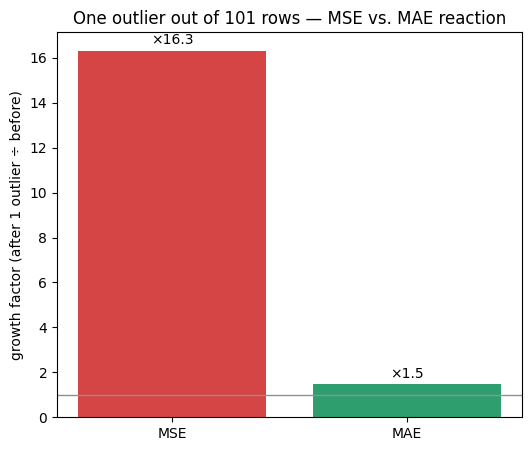

In [27]:
plt.figure(figsize=(6, 5))
plt.bar(outlier_comparison["metric"], outlier_comparison["growth factor"], color=["#d64545", "#2f9e6f"])
plt.ylabel("growth factor (after 1 outlier ÷ before)")
plt.title("One outlier out of 101 rows — MSE vs. MAE reaction")
plt.axhline(1, color="#8a8f98", linewidth=1)
for i, v in enumerate(outlier_comparison["growth factor"]):
    plt.text(i, v + 0.3, f"×{v:.1f}", ha="center")
plt.show()

**One single outlier — 1 row out of 101 — makes MSE jump about 16×,
while MAE only grows by about 1.5×.** That's the proof: MSE is not robust
to outliers, it's the *opposite* — because it squares the error, one very
wrong prediction dominates the whole cost, while MAE (which just takes the
absolute value) treats that same row as "one more medium-sized mistake"
among many. `29`'s table already noted "MAE... more robust to outliers
than MSE" — this is that exact claim, now backed by a computed ×16 vs.
×1.5 number instead of a one-line note.

## Quick Recap

| Step | What we proved | With what |
|---|---|---|
| 2–3 | A cost function turns "looks better" into a real number | `mean_squared_error()`, two candidate lines |
| 4 | Squaring stops positive/negative errors from cancelling out | mean of raw errors ≈ 0, mean of squared errors > 0 |
| 5 | The cost bowl from `29` is real, not just a sketch | swept 200 values of `m`, computed MSE at each |
| 6–8 | `mNew = mOld − learningRate × dL/dm` finds the bottom of the bowl on its own | from-scratch Gradient Descent, 8000 epochs, line-redraw plot |
| 9 | Our from-scratch answer matches the textbook method | compared against `scikit-learn`'s `LinearRegression` |
| 10 | MSE is *sensitive* to outliers, not robust | one outlier row → MSE ×16, MAE ×1.5 |

---

## FAQ — Common Mix-Ups

1. **"Is MSE robust to outliers?"**
   No — this is the single most important correction in this notebook.
   MSE *squares* every error, so one very wrong prediction contributes far
   more to the total than many small, ordinary errors combined (proven in
   Step 10: ×16 growth from one bad row). MAE is the metric that's
   comparatively robust to outliers, because it only takes the absolute
   value instead of squaring.

2. **"Why does Gradient Descent need a learning rate at all — why not
   just jump straight to the minimum?"**
   For Simple Linear Regression specifically, Ordinary Least Squares *can*
   jump straight there with a closed-form formula (that's what
   `scikit-learn`'s `.fit()` does in Step 9). Gradient Descent is the
   general-purpose tool that works even when no such shortcut formula
   exists (logistic regression, neural networks, …) — it has to feel its
   way downhill step by step instead, and the learning rate controls how
   big each feeling-around step is.

3. **"What happens if the learning rate is too big?"**
   Step 6 showed it directly: `learning_rate = 0.05` sent `m` and `c` to
   huge, meaningless numbers within 5 steps — each update overshoots the
   bottom of the bowl and lands further out than before, instead of
   settling in. Too small, and training just takes far more epochs to
   reach the same answer.

4. **"Do we need calculus to *use* Gradient Descent day to day?"**
   No. `dL/dm` and `dL/dc` in Step 6 are a fixed recipe, derived once —
   the same way you don't re-derive how a `HashMap` resizes before calling
   `.put()`. Knowing *what* the update rule does (step downhill,
   proportional to slope) matters far more day-to-day than re-deriving it.

5. **"Where exactly does the line get 'drawn multiple times'?"**
   In Step 7's `for epoch in range(epochs + 1):` loop — specifically the
   two lines `m = m - learning_rate * dL_dm` and
   `c = c - learning_rate * dL_dc`, which run once per epoch, 8000 times
   total. Step 2's two lines are just a before/after snapshot for
   comparison, not the redraw process itself; Step 8 plots several of the
   snapshots that loop actually saved.

---

## Interview-Style Q&A

**Q: Write the Gradient Descent update rule for the slope `m`, and explain
each term.**
A: `mNew = mOld − learningRate × dL/dm`. `dL/dm` is the derivative (slope)
of the cost function with respect to `m` at the current guess — it points
uphill. Subtracting a small multiple of it (`learningRate`) moves `m` a
step downhill, toward lower cost. The same update runs for `c` at the same
time, using `dL/dc`.

**Q: Why is MSE described as "sensitive to outliers," concretely?**
A: Because the error term is squared before averaging. A residual of 10 is
20× worse than average, but its squared contribution is 100 units — far
more than proportionate. One extreme row can dominate the total MSE even
if every other row fits the line well, which is exactly what Step 10
measured (×16 MSE growth from a single outlier vs. ×1.5 for MAE).

**Q: If Gradient Descent and Ordinary Least Squares reach almost the same
`m` and `c` for Simple Linear Regression, why bother with Gradient
Descent at all?**
A: For plain Linear Regression, OLS is strictly better — it's exact and
non-iterative. Gradient Descent earns its keep on models where no
closed-form formula exists (logistic regression, neural networks with many
layers, …). Simple Linear Regression is just the easiest place to build
and sanity-check a Gradient Descent implementation, because you already
have a trustworthy answer (OLS) to check it against.

**Q: What would happen to the cost bowl from Step 5 if the learning rate
in Gradient Descent were replaced by a fixed step size that never
shrinks?**
A: It could overshoot the minimum indefinitely, oscillating back and forth
across the bottom of the bowl (or, if the step is too large relative to
the bowl's steepness, diverge outward entirely — exactly what happened
with `learning_rate = 0.05` in Step 6). The learning rate has to be small
enough, relative to the steepness of the bowl, for each step to actually
land closer to the minimum than the last.

---

## Coming Up Next

- ⬜ Gradient Descent as its own topic — batch vs. stochastic vs. mini-batch,
  and learning-rate scheduling, once we reach a model where the
  closed-form shortcut (OLS) isn't available.
- ⬜ Logistic Regression — the first place a genuinely different cost
  function (cross-entropy, previewed in `29`) becomes necessary instead of
  optional.